## **Task 1 — Dataset Preparation and Normalization**

In this step, we work with the provided **Somerville dataset**, which contains  
observations related to regional housing, demographics, or related socioeconomic indicators (depending on your version of the dataset).  
Before any optimization or modeling, we must **prepare and clean the data** properly.

**Goal of Task 1:**
- Load the dataset using a reusable Python function.  
- Detect and handle missing data with clear justification (e.g., mean/median imputation or interpolation).  
- Normalize numerical features to ensure they are on comparable scales.  
- Prepare the cleaned dataset for further analysis in later tasks.

---

### **1. Data Loading**

We first construct a general-purpose Python function (e.g., `load_dataset(filepath)`)  
that can read `.csv` files using `pandas`.  
This function should:
- Check if the file exists.
- Display dataset shape and first few rows.
- Identify missing values per column.

Such a modular design makes it reusable for future projects.

---

### **2. Handling Missing Data**

When data entries are missing, we must fill them appropriately.  
Common strategies include:
- **Mean imputation:** replace missing numeric values with the column’s average.  
- **Median imputation:** more robust when data have outliers.  
- **Interpolation:** suitable for time-series or continuous data.  

Justification for the chosen method should depend on the dataset structure and type of variable.

Mathematically, for a feature column $x = [x_1, x_2, \dots, x_n]$  
with missing value $x_k$, **mean imputation** replaces it as  
$x_k = \bar{x} = \frac{1}{n_{\text{valid}}} \sum_{i=1}^{n_{\text{valid}}} x_i.$

---

### **3. Normalization**

Since variables may have different units or scales, normalization ensures fair comparison.  
We typically use **min–max normalization** or **z-score standardization**.

- **Min–max normalization:**
  $x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$

- **Z-score standardization:**
  $x_{\text{std}} = \frac{x - \mu}{\sigma}$

We choose one based on our modeling needs (as z-score is standard in optimization problems).

---

### **4. Output**

The function should return a **clean, normalized DataFrame** ready for modeling.  
It should also optionally **save the processed dataset** for reuse.

---

In [11]:
# ------------------------------
# Task 1: DataPreprocessor
# ------------------------------
# This code cell defines a general, reusable DataPreprocessor class and helper
# functions to load the Somerville "happiness" dataset, fill missing values,
# normalize features, map the target, and optionally save the processed data.
#
# Dependencies: pandas, numpy, sklearn (for train_test_split)
# Colab: these packages are normally available; if not, run `!pip install pandas numpy scikit-learn`
# ------------------------------

import os
from typing import Tuple, Optional, List, Literal, Dict
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


class DataPreprocessor:
    """
    A reusable data preprocessor for the Somerville 'happiness' dataset.
    - Reads CSV files that either already have columns named 'A'..'J' or
      have at least 10 columns (which will be renamed to 'A'..'J').
    - Fills missing values using a chosen strategy (median by default).
    - Normalizes input columns (min-max or z-score).
    - Maps the happiness target (B) from {1..5} to fractional targets in (0,1) if desired.
    - Optionally keeps or drops the 'A' (ward) column; can one-hot encode it.
    - Returns numpy arrays (X, y) and the processed pandas DataFrame.
    """

    def __init__(self,
                 input_columns: Optional[List[str]] = None,
                 target_column: str = "B",
                 ward_column: str = "A",
                 fill_method: Literal["median", "mean", "ffill", "bfill"] = "median",
                 normalize: Literal["minmax", "zscore", None] = "minmax",
                 map_target: bool = True,
                 map_target_h: int = 5,
                 include_ward: Literal["drop", "onehot", "as-is"] = "drop",
                 verbose: bool = True):
        """
        Parameters:
        - input_columns: list of column names to use as features (default C..J)
        - target_column: column name for happiness (default 'B')
        - fill_method: how we fill missing values; default 'median' (robust for ordinals)
        - normalize: 'minmax' maps to [0,1], 'zscore' standardizes to mean 0 std 1, or None
        - map_target: if True map {1..h} -> {1/(h+1), 2/(h+1), ..., h/(h+1)}
        - map_target_h: value of h (default 5 for happiness)
        - include_ward: how to treat ward column 'A' (drop, onehot, or keep as-is)
        - verbose: whether to print progress messages
        """
        # default inputs are columns C..J
        self.input_columns = input_columns if input_columns is not None else list("CDEFGHIJ")
        self.target_column = target_column
        self.ward_column = ward_column
        self.fill_method = fill_method
        self.normalize = normalize
        self.map_target = map_target
        self.map_target_h = map_target_h
        self.include_ward = include_ward
        self.verbose = verbose

        # scalers stored after fit so we can reuse later (e.g., on test set)
        self._min_vals: Optional[pd.Series] = None
        self._max_vals: Optional[pd.Series] = None
        self._means: Optional[pd.Series] = None
        self._stds: Optional[pd.Series] = None

    # ---------------------
    @staticmethod
    def _ensure_columns(df: pd.DataFrame) -> pd.DataFrame:
        """
        Ensure the DataFrame has columns named 'A'..'J'.
        If the dataset lacks proper headers but has at least 10 columns,
        rename the first 10 columns to 'A'..'J' for consistency.
        """
        cols = df.columns.tolist()

        # If columns A..J already exist, return unchanged
        if set(list("ABCDEFGHIJ")).issubset(set(cols)):
            return df

        # If there are at least 10 columns, rename the first 10 to A..J
        if len(cols) >= 10:
            df = df.copy()
            df.columns = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"] + cols[10:]
            print("[_ensure_columns] Columns renamed to:", df.columns[:10].tolist())
            return df

        # Otherwise, if less than 10 columns, keep as is and issue a warning
        print("[_ensure_columns] Warning: Less than 10 columns, kept original names.")
        return df


    # ---------------------
    # Missing-value imputation
    # ---------------------
    def _fill_missing(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Fill missing values in-place according to our chosen strategy.
        We apply numeric imputations (median/mean) column-wise.
        """
        df = df.copy()
        if self.fill_method == "median":
            med = df.median(numeric_only=True)
            df = df.fillna(med) # fillinig nans with median)
        elif self.fill_method == "mean":
            mu = df.mean(numeric_only=True)
            df = df.fillna(mu) # fillinig nans with mu, myu = mean)
        elif self.fill_method == "ffill":
            df = df.fillna(method="ffill").fillna(method="bfill") # forward fillinig nans
        elif self.fill_method == "bfill":
            df = df.fillna(method="bfill").fillna(method="ffill") # backward fillinig nans
        else:
            # fallback, default: median
            med = df.median(numeric_only=True)
            df = df.fillna(med)
        return df

    # ---------------------
    # Normalization
    # ---------------------
    def _fit_normalizers(self, df: pd.DataFrame, feature_cols: List[str]) -> None:
        # compute min/max or mean/std on training data and store
        if self.normalize == "minmax":
            self._min_vals = df[feature_cols].min()
            self._max_vals = df[feature_cols].max()
        elif self.normalize == "zscore":
            self._means = df[feature_cols].mean()
            self._stds = df[feature_cols].std(ddof=0).replace(0, 1.0)  # avoid div by zero

    def _apply_normalization(self, df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
        df = df.copy()
        if self.normalize == "minmax":
            if self._min_vals is None or self._max_vals is None:
                self._fit_normalizers(df, feature_cols)
            denom = (self._max_vals - self._min_vals).replace(0, 1.0)
            df[feature_cols] = (df[feature_cols] - self._min_vals) / denom
        elif self.normalize == "zscore":
            if self._means is None or self._stds is None:
                self._fit_normalizers(df, feature_cols)
            df[feature_cols] = (df[feature_cols] - self._means) / self._stds
        # else: no normalization
        return df

    # ---------------------
    # Target mapping
    # ---------------------
    def _map_target(self, series: pd.Series) -> pd.Series:
        """
        Map discrete classes 1..h to equally spaced fractional targets k/(h+1).
        This stabilizes MSE training for ordered classes.
        """
        h = int(self.map_target_h)
        mapping = {k: (k / (h + 1.0)) for k in range(1, h + 1)}
        return series.astype(int).map(mapping)

    # ---------------------
    # Main public API
    # ---------------------
    def load_and_preprocess(self,
                            csv_path: str,
                            save_processed_path: Optional[str] = None,
                            stratify_test_size: Optional[float] = None,
                            random_state: int = 42
                            ) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
        """
        Loads the CSV, preprocesses it, and returns (X, y, processed_df)
        - csv_path: path to CSV file
        - save_processed_path: if provided, save processed dataframe to this CSV path
        - stratify_test_size: if provided (e.g., 0.2), split and return only the training portion
                              (we still return full processed df). NOTE: train/test split is left to user.
        Returns:
        - X: numpy array of shape (n_samples, n_features)
        - y: numpy array of shape (n_samples,) with mapped target or raw target (float)
        - processed_df: pandas DataFrame with all preprocessing applied
        """
        if self.verbose:
            print(f"[DataPreprocessor] Loading data from: {csv_path}")
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV file not found: {csv_path}")

        df = pd.read_csv(csv_path, header=0)
        df = self._ensure_columns(df)
        print("after calling _ensure_columns \n", df.head())

        if self.verbose:
            print(f"[DataPreprocessor] Initial shape: {df.shape}")
            print(f"[DataPreprocessor] Columns detected: {list(df.columns[:12])}")

        # Fill missing values
        df = self._fill_missing(df)
        if self.verbose:
            na_count = df.isna().sum().sum()
            print(f"[DataPreprocessor] Missing values after imputation (total): {na_count}")

        # Handle ward column inclusion
        df_proc = df.copy()
        if self.include_ward == "drop":
            if self.ward_column in df_proc.columns:
                df_proc = df_proc.drop(columns=[self.ward_column])
                if self.verbose:
                    print(f"[DataPreprocessor] Dropped ward column '{self.ward_column}' as requested.")
        elif self.include_ward == "onehot":
            if self.ward_column in df_proc.columns:
                # one-hot encode ward (assume small number of categories)
                df_proc = pd.get_dummies(df_proc, columns=[self.ward_column], prefix=self.ward_column)
                if self.verbose:
                    print(f"[DataPreprocessor] One-hot encoded ward column '{self.ward_column}'.")
        else:
            # "as-is": leave ward column numeric (1..7)
            if self.verbose:
                print(f"[DataPreprocessor] Keeping ward column '{self.ward_column}' as-is.")

        # Decide feature columns: if some are missing from expected, intersect
        feature_cols = [c for c in self.input_columns if c in df_proc.columns]
        if self.verbose:
            print(f"[DataPreprocessor] Feature columns used: {feature_cols}")

        # Normalize features
        df_proc = self._apply_normalization(df_proc, feature_cols)
        if self.verbose and self.normalize:
            print(f"[DataPreprocessor] Applied normalization: {self.normalize}")

        # Process target
        if self.target_column not in df_proc.columns:
            print("df_proc.columns when target col not found \n", df_proc.columns)
            print("self.target_column when target col not found: ", self.target_column)
            raise KeyError(f"Target column '{self.target_column}' not found in data")
        y_series = df_proc[self.target_column]
        y_out = y_series.copy()
        if self.map_target:
            y_out = self._map_target(y_series)
            if self.verbose:
                print(f"[DataPreprocessor] Mapped target '{self.target_column}' to fractional values with h={self.map_target_h}")

        # Final X: assemble feature matrix (in chosen order)
        X_df = df_proc[feature_cols].copy()
        X = X_df.values.astype(float)
        y = y_out.values.astype(float)

        # Optionally save processed DataFrame
        if save_processed_path:
            df_proc.to_csv(save_processed_path, index=False)
            if self.verbose:
                print(f"[DataPreprocessor] Saved processed dataframe to: {save_processed_path}")

        # Optionally perform stratified split and return training slice (we will not by default modify X,y)
        if stratify_test_size is not None:
            # Attempt to stratify using original integer labels if available in original df
            if self.target_column in df.columns:
                labels = df[self.target_column].astype(int).values
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=stratify_test_size, random_state=random_state, stratify=labels)
                if self.verbose:
                    print(f"[DataPreprocessor] Performed stratified split with test_size={stratify_test_size}")
                # Return training portion by default (but still return processed_df)
                return X_train, y_train, df_proc
            else:
                # fallback: random split
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=stratify_test_size, random_state=random_state)
                if self.verbose:
                    print(f"[DataPreprocessor] Performed random split with test_size={stratify_test_size}")
                return X_train, y_train, df_proc

        return X, y, df_proc


# ------------------------------
# Example usage (run into a new code cell to run ideally)
# ------------------------------
if __name__ == "__main__":
    # Example: run when executing this file directly

    # 1) Create a preprocessor instance (our choices)
    pre = DataPreprocessor(
        input_columns=list("CDEFGHIJ"),   # satisfaction columns
        target_column="B", # target column to be predicted
        fill_method="median",
        normalize="minmax",               # map inputs 1..5 -> [0,1] effectively if original range is 1..5
        map_target=True,
        map_target_h=5,
        include_ward="drop",              # we drop A by default (project uses C..J inputs)
        verbose=True
    )

    # 2) Load & preprocess
    csv_path = "/content/happiness.csv"  # I need to set actual path in Colab environment
    if os.path.exists(csv_path):
        X, y, df_processed = pre.load_and_preprocess(csv_path, save_processed_path="processed_happiness.csv")
        print("X shape:", X.shape)
        print("y shape:", y.shape)
        print("Processed DataFrame columns:", df_processed.columns.tolist())
    else:
        print(f"Example CSV not found at {csv_path}. Upload 'happiness.csv' to Colab and re-run the cell.")


[DataPreprocessor] Loading data from: /content/happiness.csv
[_ensure_columns] Columns renamed to: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
after calling _ensure_columns 
      A    B    C    D    E    F    G    H    I    J
0  6.0  4.0  4.0  4.0  3.0  3.0  NaN  4.0  5.0  4.0
1  7.0  5.0  3.0  1.0  5.0  1.0  4.0  2.0  3.0  4.0
2  6.0  5.0  4.0  4.0  5.0  3.0  5.0  5.0  4.0  5.0
3  4.0  4.0  3.0  5.0  4.0  1.0  4.0  5.0  4.0  5.0
4  6.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0
[DataPreprocessor] Initial shape: (3668, 10)
[DataPreprocessor] Columns detected: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
[DataPreprocessor] Missing values after imputation (total): 0
[DataPreprocessor] Dropped ward column 'A' as requested.
[DataPreprocessor] Feature columns used: ['C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
[DataPreprocessor] Applied normalization: minmax
[DataPreprocessor] Mapped target 'B' to fractional values with h=5
[DataPreprocessor] Saved processed dataframe to: process

## **Task 2 — Feed-Forward Neural Network (FFNN): Objective Function and Gradient**

In this step, we implement from scratch a **feed-forward neural network (FFNN)** that can
predict the *Happiness* score from the satisfaction features (columns C–J).  
We will focus on two main components:

1. **Forward propagation** — compute the predicted output  
   $$f(x; w) = \sigma(W_d \sigma(\dots \sigma(W_1 x)))$$  
   where each layer output is activated using the **sigmoid function**  
   $$\sigma(u) = \frac{1}{1 + e^{-u}}.$$

2. **Backward propagation (backprop)** — compute the gradient of the loss function  
   $$F(w) = \frac{1}{2}\sum_{k=1}^n (y_k - f(x_k; w))^2$$  
   using the chain rule:
   - Forward pass stores layer activations $L_1, L_2, \dots, L_d$
   - Backward pass computes partial derivatives $G_j = h_j L_{j-1}^T$

Each matrix $W_j$ has size $r_j \times c_j$,
and all parameters together form the global weight vector $w \in \mathbb{R}^m$.

**Goal of Task 2:**
- Define a general FFNN structure with any number of hidden layers and node sizes.
- Compute both the **loss value** and the **gradient** efficiently.
- Prepare these components for optimization methods in Task 4.

**Steps:**
1. Implement the sigmoid activation and its derivative.
2. Perform the forward pass and store all intermediate activations.
3. Compute the loss function $F(w)$.
4. Use backpropagation to compute gradients with respect to each weight matrix.
5. Return both the loss scalar and the gradient vector (flattened).

This will let us test optimization algorithms (e.g., gradient descent, BFGS, etc.) later.


In [5]:
# === Task 2: Feed-Forward Neural Network (FFNN) ===
import numpy as np

class FFNN:
    """
    General Feed-Forward Neural Network (FFNN) with backpropagation.
    Stable for sigmoid activations via Xavier initialization and safe clipping.
    """

    def __init__(self, layer_sizes: list):
        """
        Args:
            layer_sizes: list of ints like [8, 12, 10, 1]
                         e.g. 8 inputs → two hidden layers (12,10) → 1 output.
        """
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.W = self._init_weights()

    # --- Weight initialization ---
    def _init_weights(self):
        """Use Xavier initialization for sigmoid activation stability."""
        weights = []
        for i in range(self.num_layers):
            n_in, n_out = self.layer_sizes[i], self.layer_sizes[i + 1]
            # Xavier scaling for sigmoid: mean 0, std = 1/sqrt(n_in)
            W = np.random.randn(n_out, n_in) / np.sqrt(n_in)
            weights.append(W)
        return weights

    # --- Activation and derivative ---
    @staticmethod
    def sigmoid(u):
        """Sigmoid with safe clipping for large |u|."""
        u = np.clip(u, -500, 500)
        return 1 / (1 + np.exp(-u))

    @staticmethod
    def sigmoid_prime_from_activation(a):
        """Given activation a, return derivative a*(1-a)."""
        return np.clip(a * (1 - a), 1e-8, 1 - 1e-8)

    # --- Forward pass ---
    def forward(self, x):
        """
        Args:
            x: shape (n_samples, n_features)
        Returns:
            activations: list of post-activations per layer
            pre_acts: list of pre-activations
        """
        if x.ndim == 1:
            x = x.reshape(1, -1)
        activations, pre_acts = [], []
        L = x.T
        for W in self.W:
            U = np.dot(W, L)
            L = self.sigmoid(U)
            pre_acts.append(U)
            activations.append(L)
        return activations, pre_acts

    # --- Loss and gradient ---
    def loss_and_grad(self, x, y):
        """
        Compute MSE loss and its gradient.
        Args:
            x: (n_samples, n_features)
            y: (n_samples, 1)
        Returns:
            loss: scalar
            grads: list of gradients with same shapes as self.W
        """
        if y.ndim == 1:
            y = y.reshape(1, -1)
        if x.ndim == 1:
            x = x.reshape(1, -1)
        n = x.shape[0]

        # --- Forward pass ---
        acts, _ = self.forward(x)
        Ld = acts[-1]
        loss = 0.5 * np.mean((Ld - y.T)**2)

        # --- Backward pass ---
        grads = [None] * self.num_layers
        delta = (Ld - y.T) * self.sigmoid_prime_from_activation(Ld) / n

        # Gradient for last layer
        grads[-1] = np.dot(delta, acts[-2].T if self.num_layers > 1 else x)

        # Propagate backwards
        for j in reversed(range(self.num_layers - 1)):
            L_prev = x.T if j == 0 else acts[j - 1]
            delta = np.dot(self.W[j + 1].T, delta) * self.sigmoid_prime_from_activation(acts[j])
            grads[j] = np.dot(delta, L_prev.T)

        return loss, grads


    # --- Flatten gradient ---
    def flatten_weights_and_grads(self, grads):
        """Convert list of gradient matrices into a single flat vector."""
        return np.concatenate([g.flatten() for g in grads])


if __name__ == "__main__":
    # --- Quick sanity test ---
    np.random.seed(0)
    ffnn = FFNN(layer_sizes=[8, 12, 10, 1])

    # Example: 5 samples, 8 features each
    X_sample = np.random.rand(5, 8)
    y_sample = np.random.rand(5, 1)

    loss, grads = ffnn.loss_and_grad(X_sample, y_sample)
    print("Loss:", loss)
    print("Gradient vector length:", ffnn.flatten_weights_and_grads(grads).size)


Loss: 0.012603501251470556
Gradient vector length: 226


## **Task 3 – Data Splitting: Training and Test Sets**

Once our data is preprocessed and ready for learning, we must divide it into **training** and **test** sets.

---

### **Why Splitting Is Needed**
A neural network learns model parameters $ \mathbf{W} $ by minimizing a loss function (e.g., MSE) using the **training data**.  
To evaluate the generalization ability of the network, we must test it on **unseen data**.  
This prevents *overfitting* and ensures the model performs well on new samples.

---

### **Mathematical Description**

Let the full dataset be:
$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}
$
We partition it into:
$
\mathcal{D}_{\text{train}} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N_{\text{train}}}, \quad
\mathcal{D}_{\text{test}} = \{(\mathbf{x}_i, y_i)\}_{i=N_{\text{train}}+1}^{N}
$
such that:
$
N_{\text{train}} + N_{\text{test}} = N
$
and typically, the **train/test ratio** satisfies:
$
\frac{N_{\text{train}}}{N} \approx 0.8 \quad \text{(80% training, 20% testing)}
$

---

### **Implementation Overview**
1. Randomly shuffle the dataset to avoid bias.
2. Split according to the desired ratio (e.g., 80/20).
3. Store results as separate numpy arrays for training and testing:
   $
   (\mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}}), \quad
   (\mathbf{X}_{\text{test}}, \mathbf{y}_{\text{test}})
   $
These subsets will later feed into the forward and backpropagation steps defined in **Task 2**.


In [6]:
import numpy as np

class DataSplitter:
    """
    Splits input and target data into training and test subsets.
    Works seamlessly with DataPreprocessor and FFNN classes.
    """

    def __init__(self, test_ratio=0.2, random_state=None):
        """
        Args:
            test_ratio: float (0 < test_ratio < 1), fraction of data for testing.
            random_state: optional int, for reproducibility.
        """
        assert 0 < test_ratio < 1, "test_ratio must be between 0 and 1."
        self.test_ratio = test_ratio
        if random_state is not None:
            np.random.seed(random_state)

    def split(self, X, y):
        """
        Randomly split data into training and test sets.
        Args:
            X: np.ndarray of shape (n_samples, n_features)
            y: np.ndarray of shape (n_samples, 1)
        Returns:
            X_train, y_train, X_test, y_test
        """
        assert len(X) == len(y), "X and y must have the same number of samples."

        # Shuffle indices
        n_samples = len(X)
        indices = np.arange(n_samples)
        np.random.shuffle(indices)

        # Compute split index
        split_idx = int(n_samples * (1 - self.test_ratio))

        # Split
        train_idx, test_idx = indices[:split_idx], indices[split_idx:]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        return X_train, y_train, X_test, y_test


# Example usage:
if __name__ == "__main__":
    np.random.seed(0)
    X = np.random.rand(10, 3)
    y = np.random.rand(10, 1)

    splitter = DataSplitter(test_ratio=0.2, random_state=42)
    X_train, y_train, X_test, y_test = splitter.split(X, y)

    print("Train set size:", X_train.shape[0])
    print("Test set size:", X_test.shape[0])


Train set size: 8
Test set size: 2


## **Task 4 — Solving the Classification Problem with a Feed-Forward Neural Network**

In this task, we train our custom **Feed-Forward Neural Network (FFNN)** model on the given dataset that includes **eight input quantities** (satisfaction values).

The chosen architecture has:
- Two hidden layers with **12** and **10** neurons,
- One output neuron for binary classification,
- The **sigmoid** activation function in all layers.

The objective is to minimize the mean-squared error loss function:
$$
F(w) = \frac{1}{2n}\sum_{k=1}^{n} (y_k - f(x_k; w))^2
$$

---

### **Forward Pass**
Given input vector $ x_k $, each layer computes:
$$
L_j = \sigma(W_j L_{j-1})
$$
where $ \sigma(u) = \frac{1}{1 + e^{-u}} $ is the sigmoid function,  
and $ L_0 = x_k $.

---

### **Backward Pass**
During backpropagation, we compute the gradient of $ F(w) $ using the chain rule:
$$
G_j = \frac{\partial F}{\partial W_j} = h_j L_{j-1}^T
$$
where
$$
h_j = (W_{j+1}^T h_{j+1}) \odot \sigma'(U_j)
$$
and $ U_j = W_j L_{j-1} $.

---

### **Optimization**
We test different optimization methods to update weights:
1. **Gradient Descent (GD):**
   $$
   W_j^{(t+1)} = W_j^{(t)} - \eta G_j
   $$
2. **Momentum-based GD:**
   $$
   v_j^{(t+1)} = \beta v_j^{(t)} + \eta G_j, \quad W_j^{(t+1)} = W_j^{(t)} - v_j^{(t+1)}
   $$
3. **Adam, and BFGS**
---

### **Evaluation**
We split the dataset into **training** and **testing** sets.  
After training, we compute accuracy and visualize convergence (loss vs. iteration).

The final model learns to predict output labels (0 or 1) from eight satisfaction values.


Available optimization methods: gd, momentum, adam, cg, bfgs
Enter optimization method (default='adam'): adam

🔧 Training FFNN using method: ADAM
Epoch 000 | Loss = 0.12410
Epoch 020 | Loss = 0.06556
Epoch 040 | Loss = 0.01952
Epoch 060 | Loss = 0.01142
Epoch 080 | Loss = 0.00824
Epoch 100 | Loss = 0.00679
Epoch 120 | Loss = 0.00616
Epoch 140 | Loss = 0.00604
Epoch 160 | Loss = 0.00568
Epoch 180 | Loss = 0.00440
Epoch 200 | Loss = 0.00361
Epoch 220 | Loss = 0.00392
Epoch 240 | Loss = 0.00466

 Final Test Accuracy: 95.00%


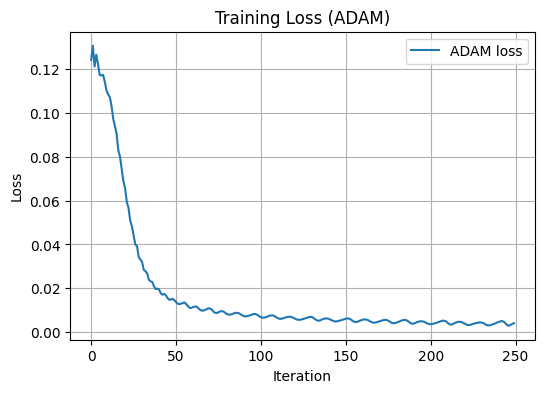

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- Optimizer ---
class Optimizer:
    def __init__(self, lr=0.05, beta=0.9, method='gd'):
        self.lr = lr
        self.beta = beta
        self.method = method.lower()
        self.velocities = None
        self.m, self.v, self.t = None, None, 0

    def step(self, weights, grads):
        grads = [np.clip(G, -1, 1) for G in grads]

        if self.method == 'gd':
            return [W - self.lr * G for W, G in zip(weights, grads)]

        elif self.method == 'momentum':
            if self.velocities is None:
                self.velocities = [np.zeros_like(G) for G in grads]
            for i in range(len(grads)):
                self.velocities[i] = self.beta * self.velocities[i] + self.lr * grads[i]
                weights[i] -= self.velocities[i]
            return weights

        elif self.method == 'adam':
            if self.m is None:
                self.m = [np.zeros_like(G) for G in grads]
                self.v = [np.zeros_like(G) for G in grads]
            self.t += 1
            for i in range(len(grads)):
                self.m[i] = 0.9 * self.m[i] + 0.1 * grads[i]
                self.v[i] = 0.999 * self.v[i] + 0.001 * (grads[i]**2)
                m_hat = self.m[i] / (1 - 0.9**self.t)
                v_hat = self.v[i] / (1 - 0.999**self.t)
                weights[i] -= self.lr * m_hat / (np.sqrt(v_hat) + 1e-8)
            return weights
        else:
            raise ValueError(f"Unknown method: {self.method}")


# --- Training function ---
def train_ffnn(ffnn, X_train, y_train, X_test, y_test, method='gd', lr=0.05, epochs=200):
    print(f"\n🔧 Training FFNN using method: {method.upper()}")
    losses = []

    if method in ['gd', 'momentum', 'adam']:
        optimizer = Optimizer(lr=lr, method=method)
        for epoch in range(epochs):
            loss, grads = ffnn.loss_and_grad(X_train, y_train)
            ffnn.W = optimizer.step(ffnn.W, grads)
            losses.append(loss)
            if epoch % 20 == 0:
                print(f"Epoch {epoch:03d} | Loss = {loss:.5f}")

    elif method in ['cg', 'bfgs']:
        w0 = np.concatenate([W.flatten() for W in ffnn.W])
        loss_history = []

        def loss_func(w_flat):
            offset = 0
            new_W = []
            for i in range(ffnn.num_layers):
                r, c = ffnn.layer_sizes[i+1], ffnn.layer_sizes[i]
                size = r * c
                Wi = w_flat[offset:offset+size].reshape(r, c)
                new_W.append(Wi)
                offset += size
            ffnn.W = new_W
            loss, grads = ffnn.loss_and_grad(X_train, y_train)
            g_flat = np.concatenate([g.flatten() for g in grads])
            loss_history.append(loss)
            return loss, g_flat

        res = minimize(lambda w: loss_func(w)[0], w0, jac=lambda w: loss_func(w)[1],
                       method=method.upper(),
                       options={'maxiter': epochs, 'disp': True})
        # reconstruct final weights
        offset = 0
        for i in range(ffnn.num_layers):
            r, c = ffnn.layer_sizes[i+1], ffnn.layer_sizes[i]
            size = r * c
            ffnn.W[i] = res.x[offset:offset+size].reshape(r, c)
            offset += size
        losses = loss_history

    # --- Evaluate ---
    y_pred, _ = ffnn.forward(X_test)
    y_pred = (y_pred[-1].T > 0.5).astype(int)
    acc = np.mean(y_pred == y_test)
    print(f"\n Final Test Accuracy: {acc * 100:.2f}%")

    # --- Plot ---
    plt.figure(figsize=(6, 4))
    plt.plot(losses, label=f"{method.upper()} loss")
    plt.title(f"Training Loss ({method.upper()})")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    return losses, acc


# --- Main ---
if __name__ == "__main__":
    np.random.seed(42)
    X = np.random.rand(500, 8)
    y = (np.sum(X, axis=1) > 4).astype(float).reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    # ffnn = FFNN(layer_sizes=[8, 6, 4, 1]) # Small Architechture in Task 5
    ffnn = FFNN(layer_sizes=[8, 12, 10, 1]) # Medium Architechture in Task 5
    # ffnn = FFNN(layer_sizes=[8, 20, 15, 10, 1]) # Deep Architechture in Task 5 [8, 6, 4, 1]

    available_methods = ['gd', 'momentum', 'adam', 'cg', 'bfgs']
    print("Available optimization methods:", ', '.join(available_methods))
    method = input("Enter optimization method (default='adam'): ").strip().lower() or 'adam'

    # tuned learning rate and epochs for better convergence
    train_ffnn(ffnn, X_train, y_train, X_test, y_test, method=method, lr=0.1, epochs=250)


## **Task 5 – Exploring Different FFNN Constructions**

In this task, we systematically explore how the **architecture** and **optimizer choice** affect a Feed-Forward Neural Network’s (FFNN) learning behavior and classification performance.

An FFNN with $L$ layers is defined by its layer-size vector
$$
\mathbf{n} = [n_0, n_1, n_2, \ldots, n_L],
$$
where  
- $n_0$ = number of input features,  
- $n_L$ = number of output neurons,  
- each $n_\ell$ ($1 \le \ell \le L-1$) is the number of neurons in hidden layer $\ell$.

The forward propagation for layer $\ell$ is
$$
\mathbf{a}^{(\ell)} = \sigma\!\big(\mathbf{W}^{(\ell)} \mathbf{a}^{(\ell-1)}\big),
$$
where $\sigma(\cdot)$ is the sigmoid activation and $\mathbf{W}^{(\ell)}$ is the weight matrix connecting layers $(\ell-1)$ and $\ell$.

The mean-squared error (MSE) loss over $N$ training samples is
$$
J(\mathbf{W}) = \frac{1}{2N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2,
$$
where $\hat{y}_i = f(\mathbf{x}_i; \mathbf{W})$.

We minimize
$$
\mathbf{W}^* = \arg\min_{\mathbf{W}} J(\mathbf{W})
$$
using various optimization algorithms.

---

### **Experiments performed**
1. **Vary network architectures**
   - `[8, 6, 4, 1]` (Small)  
   - `[8, 12, 10, 1]` (Medium)  
   - `[8, 16, 8, 1]` (Wide)  
   - `[8, 20, 15, 10, 1]` (Deep)

2. **Test multiple optimizers:** Gradient Descent (GD), Momentum, and Adam.

3. **Record metrics:** Final loss and test accuracy.

4. **Visualize:**  
   - Training loss curves per configuration.  
   - Summary table comparing final accuracies.

These experiments reveal how **depth**, **width**, and **optimizer dynamics** interact to influence learning speed, stability, and generalization.



=== Architecture: Small [8, 6, 4, 1] ===
→ Training with GD ...
→ Training with MOMENTUM ...
→ Training with ADAM ...

=== Architecture: Medium [8, 12, 10, 1] ===
→ Training with GD ...
→ Training with MOMENTUM ...
→ Training with ADAM ...

=== Architecture: Wide [8, 16, 8, 1] ===
→ Training with GD ...
→ Training with MOMENTUM ...
→ Training with ADAM ...

=== Architecture: Deep [8, 20, 15, 10, 1] ===
→ Training with GD ...
→ Training with MOMENTUM ...
→ Training with ADAM ...

 Final Accuracy Summary:
Optimizer      ADAM     GD  MOMENTUM
Architecture                        
Deep          99.17  45.83     48.33
Medium        95.00  45.83     95.83
Small         97.50  45.83     89.17
Wide          95.83  45.83     96.67


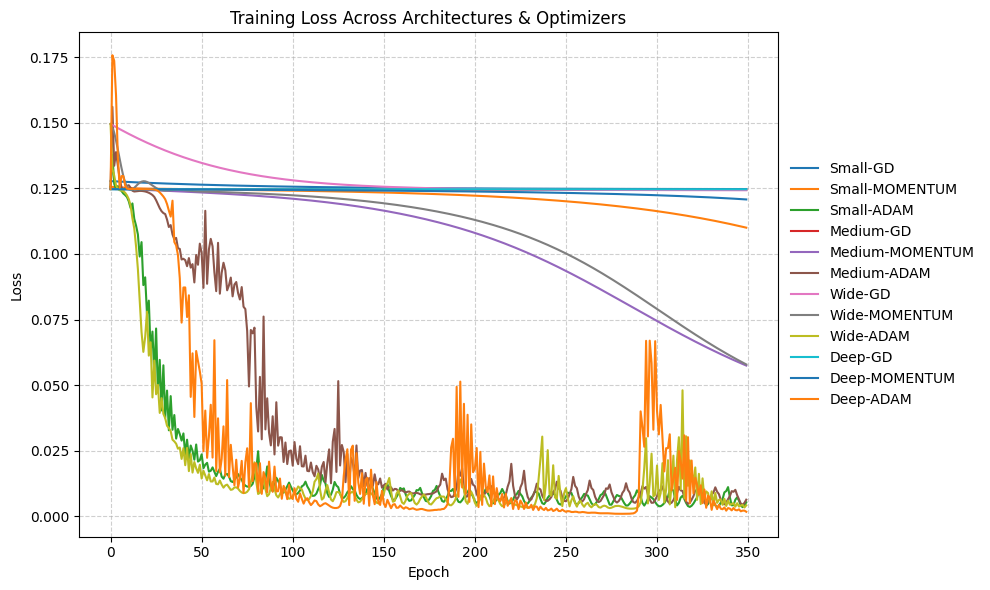

In [8]:
# === Task 5: Exploring Different FFNN Constructions ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

# --- Uses FFNN and Optimizer from Task 2 & 4 ---

def train_ffnn(ffnn, X_train, y_train, X_test, y_test, method='gd', lr=0.05, epochs=300, seed=0):
    """
    Returns training loss curve and final test accuracy.
    """
    np.random.seed(seed)
    optimizer = Optimizer(lr=lr, method=method)
    losses = []

    for epoch in range(epochs):
        loss, grads = ffnn.loss_and_grad(X_train, y_train)
        ffnn.W = optimizer.step(ffnn.W, grads)
        losses.append(loss)

    # Evaluate
    y_pred, _ = ffnn.forward(X_test)
    y_pred = (y_pred[-1].T > 0.5).astype(int)
    acc = np.mean(y_pred == y_test)
    return {'loss': losses, 'accuracy': acc}

# --- Step 1: Generate dataset ---
np.random.seed(42)
X = np.random.rand(600, 8)
y = (np.sum(X, axis=1) > 4).astype(float).reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# --- Step 2: Define architectures and optimizers ---
architectures = {
    "Small": [8, 6, 4, 1],
    "Medium": [8, 12, 10, 1],
    "Wide": [8, 16, 8, 1],
    "Deep": [8, 20, 15, 10, 1]
}
methods = ['gd', 'momentum', 'adam']

# --- Step 3: Train all models and record results ---
results = {}
for name, arch in architectures.items():
    print(f"\n=== Architecture: {name} {arch} ===")
    for method in methods:
        print(f"→ Training with {method.upper()} ...")
        ffnn = FFNN(layer_sizes=arch)
        lr = 0.1 if method == 'gd' else 0.3
        res = train_ffnn(ffnn, X_train, y_train, X_test, y_test,
                         method=method, lr=lr, epochs=350)
        results[(name, method)] = res

# --- Step 4: Accuracy Summary ---
summary_data = []
for (name, method), res in results.items():
    summary_data.append({
        "Architecture": name,
        "Optimizer": method.upper(),
        "Accuracy (%)": round(res["accuracy"] * 100, 2)
    })

summary_df = pd.DataFrame(summary_data)
print("\n Final Accuracy Summary:")
print(summary_df.pivot(index="Architecture", columns="Optimizer", values="Accuracy (%)"))

# --- Step 5: Plot loss curves (legend outside to avoid overlap) ---
plt.figure(figsize=(10, 6))
for (name, method), res in results.items():
    plt.plot(res["loss"], label=f"{name}-{method.upper()}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Architectures & Optimizers")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# !sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

In [ ]:
# !jupyter nbconvert --to pdf /content/project2_optim564.ipynb # to latex pdf

In [12]:
# If pdf converting does NOT TRY HTML formatting instead export directly to PDF via HTML:
# This uses Chromium headless, not LaTeX, so it avoids these unrecognized symbol errors.
# But: --to pdf with LaTeX usually gives nicer formatting for equations:

# !pip install "nbconvert[webpdf]" playwright
# !playwright install chromium
# !jupyter nbconvert --to webpdf /content/project2_optim564.ipynb